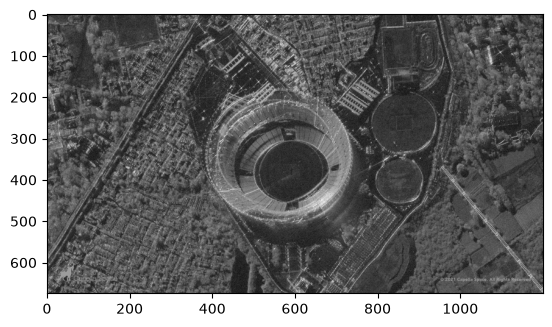

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")

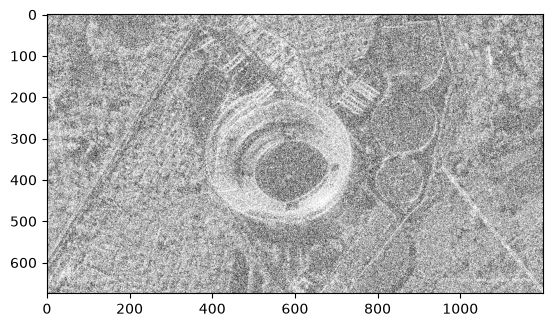

In [11]:
mean = 100
stddev = 96
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

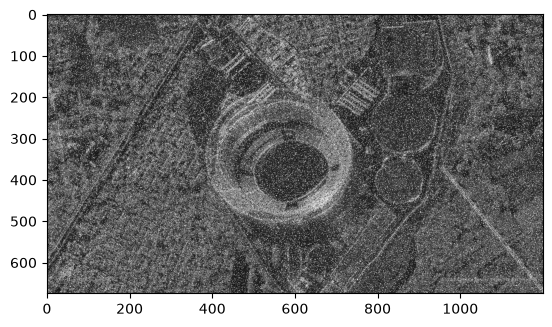

In [12]:
noise = np.random.randint(0, 11, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel  = np.where(noise == 10)


image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel]  = 255

plt.imshow(image_sp, cmap="gray")

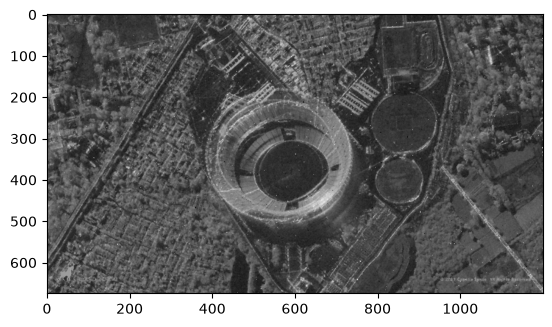

In [20]:
img_gauss_med3 = cv2.medianBlur(image_sp, 3)
plt.imshow(img_gauss_med3, cmap="gray")

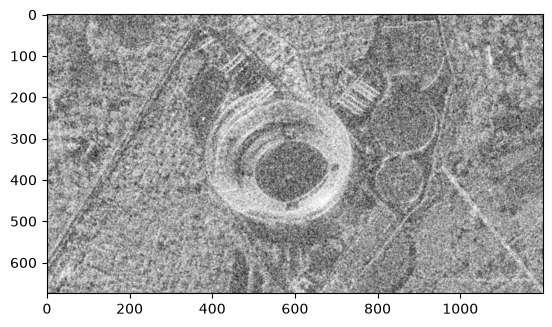

In [21]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(7,7), 1)
plt.imshow(image_gauss_gauss, cmap="gray")

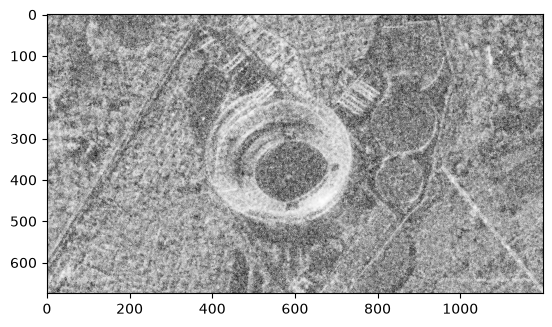

In [22]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)
plt.imshow(image_gauss_bilat, cmap="gray")

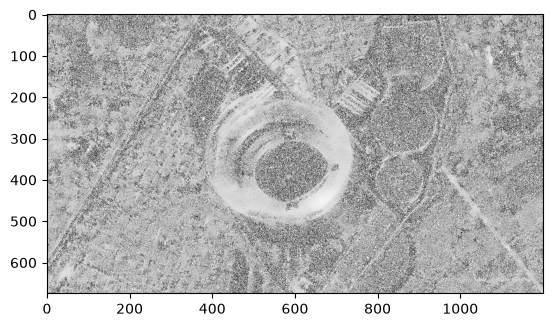

In [23]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 35)
plt.imshow(image_gauss_nlm, cmap="gray")

In [25]:
from skimage.metrics import structural_similarity, mean_squared_error

def score(name, filt):
    mse = mean_squared_error(image_gray, filt)
    ssim = structural_similarity(image_gray, filt)
    print(f"{name:10s}  MSE = {mse:8.2f}   SSIM = {ssim:.4f}")

print("Шумное (гаусс)       ", end="")
mse = mean_squared_error(image_gray, image_noise_gauss)
ssim = structural_similarity(image_gray, image_noise_gauss)
print(f"  MSE = {mse:8.2f}   SSIM = {ssim:.4f}")

print("Шумное (соль-перец)       ", end="")
mse = mean_squared_error(image_gray, image_sp)
ssim = structural_similarity(image_gray, image_sp)
print(f"  MSE = {mse:8.2f}   SSIM = {ssim:.4f}")

score("median3", img_gauss_med3)
score("gauss5",  image_gauss_gauss)
score("bilat",   image_gauss_bilat)
score("nlm20",   image_gauss_nlm)

Шумное (гаусс)         MSE = 13160.86   SSIM = 0.0962
Шумное (соль-перец)         MSE =  3566.25   SSIM = 0.1667
median3     MSE =   148.37   SSIM = 0.7699
gauss5      MSE =  9415.46   SSIM = 0.3042
bilat       MSE = 10630.25   SSIM = 0.1654
nlm20       MSE = 11773.59   SSIM = 0.1295
